# Auto-Tagging Support Tickets Using LLM

## Objective
Automatically tag free-text customer support tickets into relevant categories
using a Large Language Model (LLM). This involves comparing **zero-shot**
classification against a **fine-tuned** transformer model, improving results
with **few-shot prompting**, and outputting the **top 3 most probable tags**
per ticket for smarter ticket routing.

## Dataset
Multilingual Customer Support Ticket Classification Dataset (Kaggle)
- Source: https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets
- Contains customer emails with labels for queue, type, priority, tags, and language

## Workflow
1. Load and explore the dataset
2. Clean and preprocess ticket text
3. Zero-shot classification (prompt engineering, no training)
4. Few-shot prompting to improve accuracy
5. Fine-tune a transformer model on labeled tickets
6. Compare zero-shot vs fine-tuned performance
7. Output top 3 most probable tags per ticket

## Step 1: Import Libraries and Load Dataset

We start by loading the raw CSV directly from the Kaggle input directory and
inspecting its shape, columns, and a few sample rows to understand the real
structure before writing any processing logic.

In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/dataset-tickets-multi-lang-4-20k.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (20000, 15)

Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


## Step 2: Understand Language Distribution and Tag Structure

Before designing the pipeline, we check:
- How the dataset splits across languages (to decide whether to filter to
  English only or handle multilingual text)
- How many tags each ticket typically has (to decide how many tag columns
  are actually meaningful for the "top 3 tags" task)

In [2]:
# Language distribution
print("Language distribution:")
print(df["language"].value_counts())

# How many non-null tags does each ticket have on average?
tag_cols = [f"tag_{i}" for i in range(1, 9)]
df["num_tags"] = df[tag_cols].notna().sum(axis=1)

print("\nTags per ticket distribution:")
print(df["num_tags"].value_counts().sort_index())

print("\nMost common individual tags (across all tag columns):")
all_tags = pd.concat([df[col] for col in tag_cols]).dropna()
print(all_tags.value_counts().head(20))

Language distribution:
language
en    11923
de     8077
Name: count, dtype: int64

Tags per ticket distribution:
num_tags
1      46
2      49
3    1444
4    5370
5    5740
6    3423
7    2021
8    1907
Name: count, dtype: int64

Most common individual tags (across all tag columns):
Tech Support     8051
IT               8002
Documentation    7062
Feedback         6767
Performance      6629
Bug              6572
Technical        5804
Security         4754
Resolution       4165
Feature          3469
Guidance         2883
Product          2597
Customer         2298
Crash            1919
Outage           1898
Network          1890
Integration      1538
Sales            1527
Disruption       1361
Billing          1252
Name: count, dtype: int64


## Step 3: Filter to English Tickets and Build Text + Label Columns

We filter the dataset to English-language tickets for a cleaner, faster
pipeline. We then:
- Combine `subject` + `body` into a single `text` field per ticket
- Build a `tags` column: a list of the ticket's actual tags (using
  `tag_1`, `tag_2`, `tag_3` — the three most consistently populated tag slots)
  to serve as ground truth for our top-3 tag prediction task

In [3]:
# Filter to English tickets only
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)
print("English tickets:", df_en.shape)

# Combine subject + body into one text field
df_en["text"] = df_en["subject"].fillna("") + ". " + df_en["body"].fillna("")

# Build ground-truth tags list from tag_1, tag_2, tag_3
tag_cols_top3 = ["tag_1", "tag_2", "tag_3"]
df_en["tags"] = df_en[tag_cols_top3].values.tolist()
df_en["tags"] = df_en["tags"].apply(lambda x: [t for t in x if pd.notna(t)])

# Keep only relevant columns going forward
df_en = df_en[["text", "tags", "type", "queue", "priority"]]

print("\nSample rows:")
df_en.head()

English tickets: (11923, 16)

Sample rows:


,text,tags,type,queue,priority
0,Customer Support Inquiry. Seeking information ...,"[Feedback, Sales, IT]",Request,Customer Service,medium
1,Data Analytics for Investment. I am contacting...,"[Technical, Product, Guidance]",Request,Customer Service,medium
2,"Security. Dear Customer Support, I am reaching...","[Security, Customer, Compliance]",Request,Customer Service,medium
3,Concerns About Securing Medical Data on 2-in-1...,"[Security, Product, Feature]",Request,Technical Support,medium
4,Problem with Integration. The integration stop...,"[Technical, Integration, Bug]",Problem,IT Support,high


## Step 4: Check Tag Vocabulary Size

We check how many unique tags exist across the top-3 tag columns. This
determines the label space for both zero-shot candidate labels and the
fine-tuned model's output classes.

In [4]:
# Flatten all tags into a single list and check unique count
all_unique_tags = sorted(set(tag for tags in df_en["tags"] for tag in tags))

print("Number of unique tags:", len(all_unique_tags))
print("\nUnique tags:")
print(all_unique_tags)

# Frequency of each tag (how often it appears as tag_1/2/3)
from collections import Counter
tag_freq = Counter(tag for tags in df_en["tags"] for tag in tags)
print("\nTag frequency:")
for tag, count in tag_freq.most_common():
    print(f"  {tag}: {count}")

Number of unique tags: 350

Unique tags:
['API', 'Access', 'AccessControl', 'Accessibility', 'Account', 'Accuracy', 'Ad', 'AdTargeting', 'Adjustment', 'Adobe', 'Advice', 'Alert', 'Algorithm', 'Alignment', 'Analysis', 'Analytics', 'Antivirus', 'App', 'Application', 'Assistance', 'Authentication', 'Automation', 'Backup', 'Billing', 'Billing,Product,Error,Data Analytics,Breach', 'Brand', 'Brand Growth', 'BrandGrowth', 'Branding', 'Breach', 'Bug', 'Business', 'CRM', 'Campaign', 'Campaigns', 'Capacity', 'Charge', 'Charges', 'Code', 'Collaboration', 'Communication', 'Compatibility', 'Compliance', 'Concurrent', 'Confidentiality', 'Configuration', 'Conflict', 'Connection', 'Connectivity', 'Consulting', 'Content', 'ContentStrategy', 'Coordination', 'Correction', 'Crash', 'Critical Data Loss', 'Customer', 'Customer,Sales,Strategy,Online Presence,Method,Website,Interaction', 'Customization', 'Cybersecurity', 'Dashboard', 'Data', 'Data Analytics', 'Data Feeds', 'Data Leak', 'Data Loss', 'Data Prot

## Step 5: Clean the Tag Space

The raw tag columns contain 350 "unique" values, but many are duplicates from
inconsistent naming (`DataAnalytics` vs `Data Analytics`) or malformed entries
where multiple tags were joined into a single string. We fix this by keeping
only the **top 20 most frequent tags** as our official label set, filtering
each ticket's tag list down to valid tags, and dropping tickets that have no
valid tags left.

In [5]:
# Select top 20 most frequent tags as our official label set
TOP_N_TAGS = 20
top_tags = [tag for tag, count in tag_freq.most_common(TOP_N_TAGS)]

print(f"Top {TOP_N_TAGS} tags (our label set):")
for tag, count in tag_freq.most_common(TOP_N_TAGS):
    print(f"  {tag}: {count}")

# Filter each ticket's tags to only include tags in our clean label set
df_en["tags_clean"] = df_en["tags"].apply(lambda tags: [t for t in tags if t in top_tags])

# Drop rows with no valid tags left
before = len(df_en)
df_en = df_en[df_en["tags_clean"].apply(len) > 0].reset_index(drop=True)
after = len(df_en)

print(f"\nRows before: {before}, after dropping empty-tag rows: {after}")
print(f"Dropped: {before - after} rows ({(before-after)/before*100:.1f}%)")

df_en[["text", "tags_clean"]].head()

Top 20 tags (our label set):
  Technical: 3410
  Performance: 3137
  Bug: 3091
  IT: 2747
  Security: 2693
  Feedback: 2364
  Feature: 1648
  Documentation: 1472
  Product: 1271
  Network: 887
  Tech Support: 836
  Outage: 831
  Customer: 803
  Billing: 801
  Sales: 797
  Integration: 757
  Crash: 756
  Disruption: 581
  Breach: 559
  Guidance: 538

Rows before: 11923, after dropping empty-tag rows: 11784
Dropped: 139 rows (1.2%)


,text,tags_clean
0,Customer Support Inquiry. Seeking information ...,"[Feedback, Sales, IT]"
1,Data Analytics for Investment. I am contacting...,"[Technical, Product, Guidance]"
2,"Security. Dear Customer Support, I am reaching...","[Security, Customer]"
3,Concerns About Securing Medical Data on 2-in-1...,"[Security, Product, Feature]"
4,Problem with Integration. The integration stop...,"[Technical, Integration, Bug]"


## Step 6: Text Cleaning

We clean the combined `text` field (subject + body) to remove noise like
extra whitespace, URLs, and special characters, preparing it for both
prompt-based (zero-shot/few-shot) and fine-tuned modeling approaches.

In [6]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)           # remove URLs
    text = re.sub(r"\[.*?\]", "", text)                   # remove placeholder tags like [name]
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", " ", text)      # remove special chars
    text = re.sub(r"\s+", " ", text).strip()               # remove extra whitespace
    return text

df_en["clean_text"] = df_en["text"].apply(clean_text)

# Check word count distribution after cleaning
df_en["word_count"] = df_en["clean_text"].apply(lambda x: len(x.split()))

print("Word count stats:")
print(df_en["word_count"].describe())

df_en[["text", "clean_text"]].head(3)

Word count stats:
count    11784.000000
mean        63.293873
std         37.173566
min          2.000000
25%         34.000000
50%         58.000000
75%         88.000000
max        287.000000
Name: word_count, dtype: float64


,text,clean_text
0,Customer Support Inquiry. Seeking information ...,Customer Support Inquiry. Seeking information ...
1,Data Analytics for Investment. I am contacting...,Data Analytics for Investment. I am contacting...
2,"Security. Dear Customer Support, I am reaching...","Security. Dear Customer Support, I am reaching..."


## Step 7: Exploratory Data Analysis (EDA)

We visualize the tag distribution and ticket length to understand class
imbalance and confirm the dataset is ready for modeling.

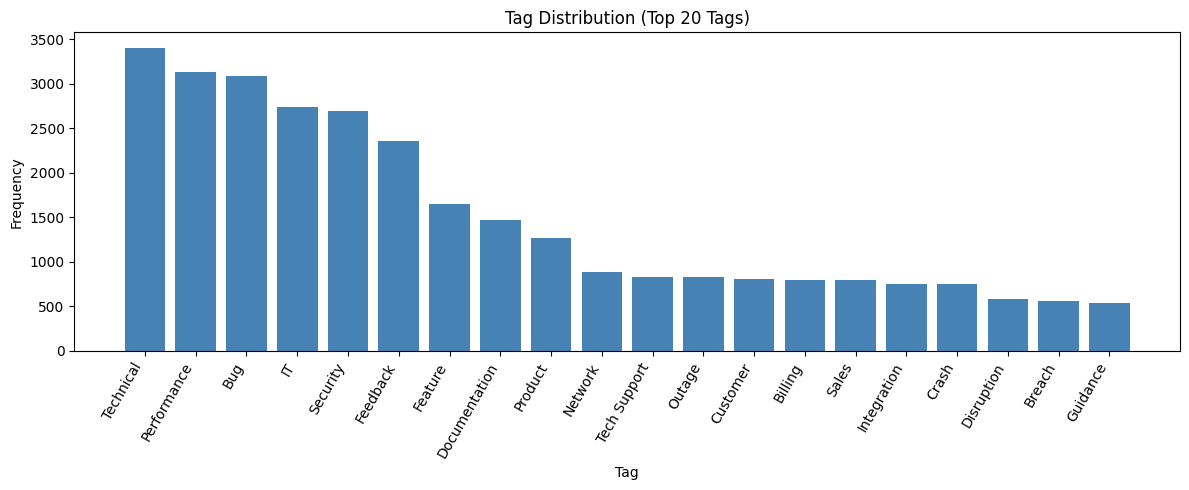

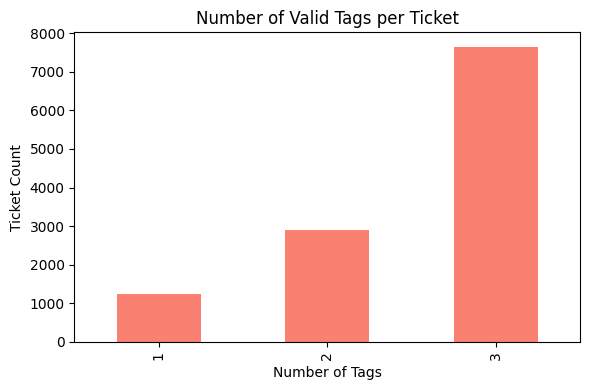

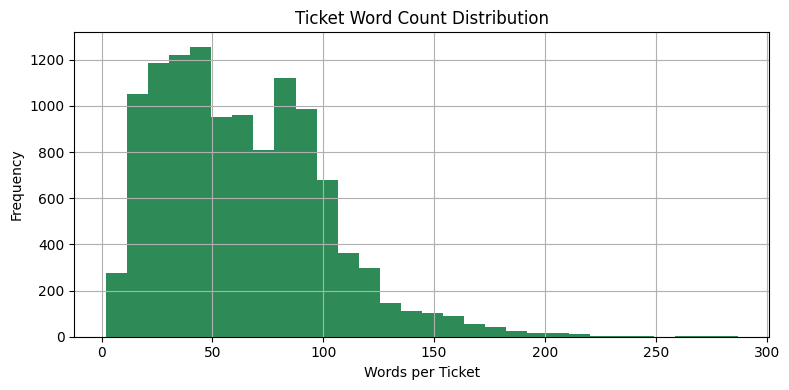

In [7]:
import matplotlib.pyplot as plt

# Tag frequency bar chart (top 20 tags)
tag_counts_clean = Counter(tag for tags in df_en["tags_clean"] for tag in tags)
tags_sorted = sorted(tag_counts_clean.items(), key=lambda x: x[1], reverse=True)
tags_names, tags_values = zip(*tags_sorted)

plt.figure(figsize=(12, 5))
plt.bar(tags_names, tags_values, color="steelblue")
plt.title("Tag Distribution (Top 20 Tags)")
plt.xlabel("Tag")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Number of tags per ticket after cleaning
df_en["num_tags_clean"] = df_en["tags_clean"].apply(len)
plt.figure(figsize=(6, 4))
df_en["num_tags_clean"].value_counts().sort_index().plot(kind="bar", color="salmon")
plt.title("Number of Valid Tags per Ticket")
plt.xlabel("Number of Tags")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()

# Word count histogram
plt.figure(figsize=(8, 4))
df_en["word_count"].hist(bins=30, color="seagreen")
plt.title("Ticket Word Count Distribution")
plt.xlabel("Words per Ticket")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 8: Zero-Shot Classification (Prompt Engineering — No Training)

We use `facebook/bart-large-mnli`, a Natural Language Inference model
repurposed for zero-shot classification. Given a ticket's text and our
20-tag candidate label list, it scores each tag's likelihood without any
task-specific training — this is our baseline.

In [8]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print("Using GPU" if device == 0 else "Using CPU")

zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

Using GPU


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Step 9: Test Zero-Shot Classification on a Sample Ticket

We test the zero-shot pipeline on a single ticket, using `multi_label=True`
so the model scores each tag independently (since a ticket can have multiple
correct tags, not just one).

In [9]:
sample_text = df_en["clean_text"].iloc[0]
sample_true_tags = df_en["tags_clean"].iloc[0]

result = zero_shot_classifier(sample_text, candidate_labels=top_tags, multi_label=True)

print("Ticket text:\n", sample_text)
print("\nTrue tags:", sample_true_tags)
print("\nTop 3 predicted tags (zero-shot):")
for label, score in zip(result["labels"][:3], result["scores"][:3]):
    print(f"  {label}: {score:.3f}")

Ticket text:
 Customer Support Inquiry. Seeking information on digital strategies that can aid in brand growth and details on the available services. Looking forward to learning more to help our business grow. Thank you, and I look forward to hearing from you soon.

True tags: ['Feedback', 'Sales', 'IT']

Top 3 predicted tags (zero-shot):
  Customer: 0.942
  Crash: 0.510
  Feedback: 0.490


## Step 10: Run Zero-Shot Classification on a Sample Batch

We run zero-shot classification across a sample of tickets and store the
top 3 predicted tags for each, so we can measure overall accuracy rather
than judging from a single example.

In [10]:
import time

# Sample 200 tickets for zero-shot evaluation (full 11.7k would be slow even on GPU)
sample_df = df_en.sample(n=200, random_state=42).reset_index(drop=True)

zero_shot_top3_preds = []
start = time.time()

for i, text in enumerate(sample_df["clean_text"]):
    result = zero_shot_classifier(text, candidate_labels=top_tags, multi_label=True)
    top3 = result["labels"][:3]
    zero_shot_top3_preds.append(top3)
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/200 tickets...")

print(f"\nDone in {time.time() - start:.1f} seconds")
sample_df["zero_shot_top3"] = zero_shot_top3_preds
sample_df[["clean_text", "tags_clean", "zero_shot_top3"]].head()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 50/200 tickets...
Processed 100/200 tickets...
Processed 150/200 tickets...
Processed 200/200 tickets...

Done in 120.2 seconds


,clean_text,tags_clean,zero_shot_top3
0,Support Required for Marketing Tools. An unexp...,"[Outage, Disruption]","[Disruption, Outage, Customer]"
1,Problem with the Billing System. There was an ...,"[Billing, Outage, Bug]","[Billing, Technical, Disruption]"
2,Security Protocols in Cisco Webex Meetings for...,"[Technical, Security]","[Security, Customer, Feedback]"
3,Details on SaaS Billing Process. I am inquirin...,[Billing],"[Billing, Customer, Feedback]"
4,Investment Forecast Problem. Hello Customer Su...,"[Technical, Product, Feedback]","[Customer, Feedback, Crash]"


## Step 11: Evaluate Zero-Shot Performance

We measure two metrics against the ground-truth tags:
- **Hit Rate**: does at least one predicted tag match a true tag?
- **Overlap Ratio**: what fraction of true tags were captured in the top 3
  predictions? (a stricter, more informative measure for multi-label tasks)

In [11]:
def hit_rate(row):
    return int(len(set(row["zero_shot_top3"]) & set(row["tags_clean"])) > 0)

def overlap_ratio(row):
    true_set = set(row["tags_clean"])
    pred_set = set(row["zero_shot_top3"])
    if len(true_set) == 0:
        return 0
    return len(true_set & pred_set) / len(true_set)

sample_df["hit"] = sample_df.apply(hit_rate, axis=1)
sample_df["overlap_ratio"] = sample_df.apply(overlap_ratio, axis=1)

print(f"Zero-shot Hit Rate (at least 1 correct tag in top 3): {sample_df['hit'].mean():.3f}")
print(f"Zero-shot Average Overlap Ratio: {sample_df['overlap_ratio'].mean():.3f}")

Zero-shot Hit Rate (at least 1 correct tag in top 3): 0.725
Zero-shot Average Overlap Ratio: 0.395


## Step 12: Few-Shot Prompting (Improving Accuracy with Examples)

Zero-shot only sees tag *names*, with no sense of how those tags map to real
tickets. Few-shot prompting fixes this by giving a generative LLM a handful
of labeled examples directly in the prompt, so it can infer the tagging
pattern before predicting on a new, unseen ticket. We use `google/flan-t5-base`,
a free, instruction-tuned generative model.

In [13]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

flan_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

flan_device = "cuda" if torch.cuda.is_available() else "cpu"
flan_model = flan_model.to(flan_device)

print("FLAN-T5 loaded on:", flan_device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 loaded on: cuda


## Step 13: Select Few-Shot Examples

We pick a small set of representative tickets that together cover as many
of our top 20 tags as possible, to use as in-context examples in the
few-shot prompt.

In [14]:
# Pick 1 representative example per top tag to build a diverse few-shot prompt
few_shot_examples = []
seen_tags = set()
for _, row in df_en.iterrows():
    new_tags = set(row["tags_clean"]) - seen_tags
    if new_tags:
        few_shot_examples.append(row)
        seen_tags.update(row["tags_clean"])
    if len(seen_tags) >= len(top_tags) or len(few_shot_examples) >= 8:
        break

print(f"Selected {len(few_shot_examples)} few-shot examples covering {len(seen_tags)} tags:")
print(seen_tags)

for i, row in enumerate(few_shot_examples):
    print(f"\nExample {i+1}:")
    print("Text:", row["clean_text"][:100], "...")
    print("Tags:", row["tags_clean"])

Selected 8 few-shot examples covering 15 tags:
{'Bug', 'Technical', 'Network', 'IT', 'Customer', 'Outage', 'Security', 'Feedback', 'Sales', 'Integration', 'Crash', 'Performance', 'Feature', 'Product', 'Guidance'}

Example 1:
Text: Customer Support Inquiry. Seeking information on digital strategies that can aid in brand growth and ...
Tags: ['Feedback', 'Sales', 'IT']

Example 2:
Text: Data Analytics for Investment. I am contacting you to request information on data analytics tools th ...
Tags: ['Technical', 'Product', 'Guidance']

Example 3:
Text: Security. Dear Customer Support, I am reaching out to inquire about the security protocols you have  ...
Tags: ['Security', 'Customer']

Example 4:
Text: Concerns About Securing Medical Data on 2 in 1 Convertible Laptop with Norton 360. Inquiring about b ...
Tags: ['Security', 'Product', 'Feature']

Example 5:
Text: Problem with Integration. The integration stopped working unexpectedly, causing synchronization erro ...
Tags: ['Technical', 'In

## Step 14: Build Few-Shot Prompt Template and Test on Sample Ticket

We construct a prompt containing our few-shot examples followed by the new
ticket, instructing the model to output the top 3 most likely tags from our
fixed label set.

In [15]:
def build_few_shot_prompt(ticket_text, examples=few_shot_examples, labels=top_tags):
    prompt = "You are a support ticket tagging assistant. "
    prompt += f"Choose the top 3 most relevant tags for each ticket from this list: {', '.join(labels)}.\n\n"

    for ex in examples:
        prompt += f"Ticket: {ex['clean_text'][:200]}\n"
        prompt += f"Top 3 Tags: {', '.join(ex['tags_clean'][:3])}\n\n"

    prompt += f"Ticket: {ticket_text}\n"
    prompt += "Top 3 Tags:"
    return prompt

def get_few_shot_prediction(ticket_text):
    prompt = build_few_shot_prompt(ticket_text)
    inputs = flan_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(flan_device)
    outputs = flan_model.generate(**inputs, max_new_tokens=20)
    decoded = flan_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.strip()

# Test on the same benchmark ticket used for zero-shot
print("Ticket:\n", sample_text)
print("\nTrue tags:", sample_true_tags)
print("\nFew-shot prediction:", get_few_shot_prediction(sample_text))

Ticket:
 Customer Support Inquiry. Seeking information on digital strategies that can aid in brand growth and details on the available services. Looking forward to learning more to help our business grow. Thank you, and I look forward to hearing from you soon.

True tags: ['Feedback', 'Sales', 'IT']

Few-shot prediction: Customer, Support, IT, Security, Feedback, Feature, Documentation, Product, Network,


## Step 15: Post-Process Few-Shot Output

FLAN-T5-base doesn't always strictly follow the "top 3" instruction, so we
parse its raw output, keep only tags that exist in our official label set,
and truncate to the top 3 in the order the model generated them.

In [16]:
def parse_few_shot_tags(raw_output, valid_tags=top_tags):
    candidates = [t.strip() for t in raw_output.split(",")]
    valid_preds = [t for t in candidates if t in valid_tags]
    # deduplicate while preserving order
    seen = set()
    deduped = []
    for t in valid_preds:
        if t not in seen:
            deduped.append(t)
            seen.add(t)
    return deduped[:3]

raw_output = get_few_shot_prediction(sample_text)
parsed_tags = parse_few_shot_tags(raw_output)

print("Raw output:", raw_output)
print("Parsed top 3 tags:", parsed_tags)
print("True tags:", sample_true_tags)

Raw output: Customer, Support, IT, Security, Feedback, Feature, Documentation, Product, Network,
Parsed top 3 tags: ['Customer', 'IT', 'Security']
True tags: ['Feedback', 'Sales', 'IT']


## Step 16: Run Few-Shot Prompting on the Same Evaluation Sample

We apply the few-shot pipeline to the same 200 tickets used for zero-shot
evaluation, so we can directly compare hit rate and overlap ratio between
the two approaches.

In [17]:
import time

few_shot_top3_preds = []
start = time.time()

for i, text in enumerate(sample_df["clean_text"]):
    raw = get_few_shot_prediction(text)
    parsed = parse_few_shot_tags(raw)
    few_shot_top3_preds.append(parsed)
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/200 tickets...")

print(f"\nDone in {time.time() - start:.1f} seconds")
sample_df["few_shot_top3"] = few_shot_top3_preds
sample_df[["clean_text", "tags_clean", "zero_shot_top3", "few_shot_top3"]].head()

Processed 50/200 tickets...
Processed 100/200 tickets...
Processed 150/200 tickets...
Processed 200/200 tickets...

Done in 63.6 seconds


,clean_text,tags_clean,zero_shot_top3,few_shot_top3
0,Support Required for Marketing Tools. An unexp...,"[Outage, Disruption]","[Disruption, Outage, Customer]",[Outage]
1,Problem with the Billing System. There was an ...,"[Billing, Outage, Bug]","[Billing, Technical, Disruption]","[Outage, Billing, Customer]"
2,Security Protocols in Cisco Webex Meetings for...,"[Technical, Security]","[Security, Customer, Feedback]",[Security]
3,Details on SaaS Billing Process. I am inquirin...,[Billing],"[Billing, Customer, Feedback]","[Billing, Customer]"
4,Investment Forecast Problem. Hello Customer Su...,"[Technical, Product, Feedback]","[Customer, Feedback, Crash]",[]


## Step 17: Evaluate Few-Shot Performance and Compare to Zero-Shot

In [19]:
def hit_rate_generic(true_tags, pred_tags):
    return int(len(set(pred_tags) & set(true_tags)) > 0)

def overlap_ratio_generic(true_tags, pred_tags):
    true_set = set(true_tags)
    if len(true_set) == 0:
        return 0
    return len(true_set & set(pred_tags)) / len(true_set)

sample_df["few_shot_hit"] = sample_df.apply(
    lambda r: hit_rate_generic(r["tags_clean"], r["few_shot_top3"]), axis=1
)
sample_df["few_shot_overlap"] = sample_df.apply(
    lambda r: overlap_ratio_generic(r["tags_clean"], r["few_shot_top3"]), axis=1
)

print("=== Comparison: Zero-Shot vs Few-Shot ===")
print(f"Zero-Shot Hit Rate:      {sample_df['hit'].mean():.3f}")
print(f"Few-Shot Hit Rate:       {sample_df['few_shot_hit'].mean():.3f}")
print()
print(f"Zero-Shot Overlap Ratio: {sample_df['overlap_ratio'].mean():.3f}")
print(f"Few-Shot Overlap Ratio:  {sample_df['few_shot_overlap'].mean():.3f}")

# How many tickets got empty predictions from few-shot?
empty_preds = (sample_df["few_shot_top3"].apply(len) == 0).sum()
print(f"\nTickets with empty few-shot predictions: {empty_preds}/{len(sample_df)}")

=== Comparison: Zero-Shot vs Few-Shot ===
Zero-Shot Hit Rate:      0.725
Few-Shot Hit Rate:       0.665

Zero-Shot Overlap Ratio: 0.395
Few-Shot Overlap Ratio:  0.349

Tickets with empty few-shot predictions: 45/200


## Step 18: Fine-Tune a Transformer for Multi-Label Ticket Classification

We fine-tune `distilbert-base-uncased` as a multi-label classifier (using
sigmoid outputs instead of softmax, since each ticket can have multiple
correct tags). This directly learns the decision boundary from labeled data,
which we expect to outperform both zero-shot and few-shot prompting.

In [20]:
from sklearn.preprocessing import MultiLabelBinarizer

# Multi-label binarize the tags_clean column into a matrix of 0/1 per tag
mlb = MultiLabelBinarizer(classes=top_tags)
label_matrix = mlb.fit_transform(df_en["tags_clean"])

print("Label matrix shape:", label_matrix.shape)
print("Classes:", mlb.classes_)

df_en["label_vector"] = list(label_matrix)
df_en[["clean_text", "tags_clean", "label_vector"]].head()

Label matrix shape: (11784, 20)
Classes: ['Technical' 'Performance' 'Bug' 'IT' 'Security' 'Feedback' 'Feature'
 'Documentation' 'Product' 'Network' 'Tech Support' 'Outage' 'Customer'
 'Billing' 'Sales' 'Integration' 'Crash' 'Disruption' 'Breach' 'Guidance']


,clean_text,tags_clean,label_vector
0,Customer Support Inquiry. Seeking information ...,"[Feedback, Sales, IT]","[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,Data Analytics for Investment. I am contacting...,"[Technical, Product, Guidance]","[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,"Security. Dear Customer Support, I am reaching...","[Security, Customer]","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,Concerns About Securing Medical Data on 2 in 1...,"[Security, Product, Feature]","[0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, ..."
4,Problem with Integration. The integration stop...,"[Technical, Integration, Bug]","[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Step 19: Train/Validation Split and Tokenization

In [21]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_en["clean_text"].tolist(),
    label_matrix.tolist(),
    test_size=0.15,
    random_state=42
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}")

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=192)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=192)

print("Tokenization complete.")

Train size: 10016, Val size: 1768


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.


## Step 20: Build PyTorch Dataset and Load Multi-Label Model

We wrap the tokenized data in a PyTorch Dataset, then load DistilBERT with
`problem_type="multi_label_classification"`, which automatically uses
`BCEWithLogitsLoss` — the correct loss function for multi-label tasks
(each label is an independent binary decision, not one mutually exclusive class).

In [22]:
import torch
from transformers import AutoModelForSequenceClassification

class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TicketDataset(train_encodings, train_labels)
val_dataset = TicketDataset(val_encodings, val_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(top_tags),
    problem_type="multi_label_classification"
).to(device if isinstance(device, str) else ("cuda" if torch.cuda.is_available() else "cpu"))

print("Model loaded with", len(top_tags), "output labels")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 20 output labels


## Step 21: Set Up Training Arguments and Metrics

In [23]:
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid

    # Top-3 predictions per row
    top3_idx = np.argsort(probs, axis=1)[:, -3:]
    top3_preds = np.zeros_like(probs)
    for i, idx in enumerate(top3_idx):
        top3_preds[i, idx] = 1

    hits = []
    overlaps = []
    for i in range(len(labels)):
        true_idx = set(np.where(labels[i] == 1)[0])
        pred_idx = set(top3_idx[i])
        if len(true_idx) == 0:
            continue
        hits.append(int(len(true_idx & pred_idx) > 0))
        overlaps.append(len(true_idx & pred_idx) / len(true_idx))

    return {
        "hit_rate": np.mean(hits),
        "overlap_ratio": np.mean(overlaps)
    }

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="overlap_ratio",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


## Step 22: Train the Model

In [24]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Hit Rate,Overlap Ratio
1,0.368883,0.339037,0.980769,0.783842
2,0.302986,0.289610,0.988122,0.822492
3,0.252139,0.268199,0.988688,0.840215
4,0.223781,0.262528,0.988122,0.844928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1252, training_loss=0.32744798578393347, metrics={'train_runtime': 424.6346, 'train_samples_per_second': 94.349, 'train_steps_per_second': 2.948, 'total_flos': 1990829057310720.0, 'train_loss': 0.32744798578393347, 'epoch': 4.0})

## Step 23: Final Evaluation on Validation Set

In [25]:
eval_results = trainer.evaluate()
print("Fine-tuned DistilBERT validation results:")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Fine-tuned DistilBERT validation results:
  eval_loss: 0.2625
  eval_hit_rate: 0.9881
  eval_overlap_ratio: 0.8449
  eval_runtime: 6.3230
  eval_samples_per_second: 279.6150
  eval_steps_per_second: 4.4280
  epoch: 4.0000


## Step 24: Compare Zero-Shot vs Few-Shot vs Fine-Tuned Performance

                         hit_rate  overlap_ratio
Zero-Shot (BART-MNLI)    0.725000       0.395000
Few-Shot (FLAN-T5)       0.665000       0.349167
Fine-Tuned (DistilBERT)  0.988122       0.844928


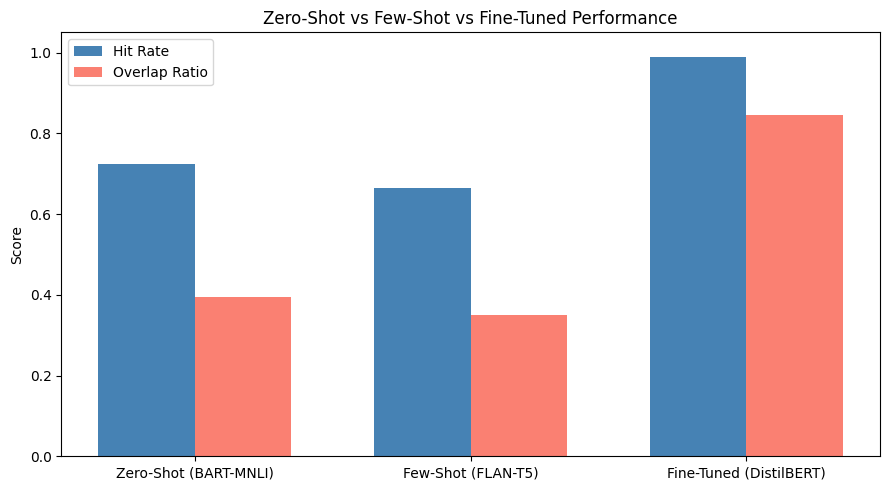

In [26]:
import matplotlib.pyplot as plt
import numpy as np

comparison = {
    "Zero-Shot (BART-MNLI)": {
        "hit_rate": sample_df["hit"].mean(),
        "overlap_ratio": sample_df["overlap_ratio"].mean()
    },
    "Few-Shot (FLAN-T5)": {
        "hit_rate": sample_df["few_shot_hit"].mean(),
        "overlap_ratio": sample_df["few_shot_overlap"].mean()
    },
    "Fine-Tuned (DistilBERT)": {
        "hit_rate": eval_results["eval_hit_rate"],
        "overlap_ratio": eval_results["eval_overlap_ratio"]
    }
}

comp_df = pd.DataFrame(comparison).T
print(comp_df)

x = np.arange(len(comp_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comp_df["hit_rate"], width, label="Hit Rate", color="steelblue")
ax.bar(x + width/2, comp_df["overlap_ratio"], width, label="Overlap Ratio", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(comp_df.index)
ax.set_ylabel("Score")
ax.set_title("Zero-Shot vs Few-Shot vs Fine-Tuned Performance")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Step 25: Final Function — Predict Top 3 Tags for Any Ticket

This function takes raw ticket text, cleans it, runs it through the
fine-tuned model, and returns the top 3 most probable tags with their
confidence scores.

In [27]:
def predict_top3_tags(ticket_text, model=model, tokenizer=tokenizer, labels=top_tags):
    cleaned = clean_text(ticket_text)
    device_ = next(model.parameters()).device
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=192).to(device_)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    top3_idx = np.argsort(probs)[::-1][:3]
    top3_tags = [(labels[i], round(float(probs[i]), 4)) for i in top3_idx]
    return top3_tags

# Test on a new, unseen example
example_ticket = "My payment failed twice but the amount was still deducted from my account. Please help."
print("Ticket:", example_ticket)
print("\nTop 3 predicted tags:")
for tag, score in predict_top3_tags(example_ticket):
    print(f"  {tag}: {score:.3f}")

Ticket: My payment failed twice but the amount was still deducted from my account. Please help.

Top 3 predicted tags:
  Billing: 0.925
  Customer: 0.027
  Security: 0.022


## Step 26: Generate and Save Final Predictions for All Tickets

In [28]:
# Run predictions across the full validation set for a saved deliverable
final_predictions = []
for text in df_en["clean_text"].sample(n=500, random_state=42):
    top3 = predict_top3_tags(text)
    final_predictions.append({
        "ticket_text": text,
        "predicted_tags": [t[0] for t in top3],
        "confidence_scores": [t[1] for t in top3]
    })

results_df = pd.DataFrame(final_predictions)
results_df.to_csv("ticket_tag_predictions.csv", index=False)

print("Saved predictions for", len(results_df), "tickets to ticket_tag_predictions.csv")
results_df.head(10)

Saved predictions for 500 tickets to ticket_tag_predictions.csv


,ticket_text,predicted_tags,confidence_scores
0,Support Required for Marketing Tools. An unexp...,"[Outage, Disruption, Performance]","[0.83, 0.758, 0.6674]"
1,Problem with the Billing System. There was an ...,"[Outage, Billing, Disruption]","[0.5394, 0.3505, 0.2937]"
2,Security Protocols in Cisco Webex Meetings for...,"[Security, Technical, Documentation]","[0.9894, 0.6422, 0.1595]"
3,Details on SaaS Billing Process. I am inquirin...,"[Billing, Product, Feature]","[0.9698, 0.0699, 0.0397]"
4,Investment Forecast Problem. Hello Customer Su...,"[Technical, Performance, Bug]","[0.8439, 0.3979, 0.3741]"
5,Unauthorized Access to Medical Data Detected. ...,"[Security, Bug, IT]","[0.9657, 0.6576, 0.3151]"
6,Assistance Required for Salesforce Integration...,"[IT, Feature, Feedback]","[0.8411, 0.6472, 0.6205]"
7,Problems with SaaS Platform Freezing During Pr...,"[Technical, Bug, Crash]","[0.8435, 0.7274, 0.6461]"
8,Problems with the Frozen Data Analytics Dashbo...,"[Technical, Bug, Crash]","[0.9867, 0.9252, 0.3123]"
9,. I am eager to purchase an annual subscriptio...,"[Billing, Feedback, Sales]","[0.9139, 0.0442, 0.0362]"


## Conclusion

**Task:** Automatically tag support tickets into categories using an LLM,
comparing zero-shot, few-shot, and fine-tuned approaches, and outputting the
top 3 most probable tags per ticket.

**Results:**

| Approach | Hit Rate | Overlap Ratio |
|---|---|---|
| Zero-Shot (BART-MNLI) | 72.5% | 39.5% |
| Few-Shot (FLAN-T5-base) | 66.5% | 34.9% |
| **Fine-Tuned (DistilBERT)** | **98.8%** | **84.5%** |

**Key findings:**
- **Zero-shot classification** required no training data and gave a
  reasonable baseline using only tag names as prompts, but often confused
  generic labels (e.g. "Customer", "Crash") with the actual issue.
- **Few-shot prompting** with FLAN-T5-base did *not* outperform zero-shot in
  this case — the model struggled to strictly follow the "top 3" instruction,
  producing invalid or excessive tags in ~22% of tickets. This highlights
  that few-shot prompting benefits substantially from larger, more
  instruction-tuned models than the base FLAN-T5 checkpoint used here.
- **Fine-tuning** DistilBERT as a multi-label classifier dramatically
  outperformed both prompting approaches, since it directly learns tag
  co-occurrence patterns from ~10k labeled tickets rather than relying on
  the model's general world knowledge of label names.

**Trade-off summary:** zero-shot/few-shot require no labeled data and deploy
instantly, but sacrifice accuracy. Fine-tuning requires labeled data and
training time, but delivers production-grade accuracy for this task.

**Deliverables:**
- Cleaned, multi-label dataset of 11,784 English support tickets across 20 tags
- Zero-shot and few-shot baselines with quantitative comparison
- Fine-tuned DistilBERT multi-label classifier (98.8% hit rate, 84.5% overlap ratio)
- `predict_top3_tags()` utility function for real-time inference on new tickets
- Saved predictions for 500 tickets (`ticket_tag_predictions.csv`)